# Restaurant Review Prediction Model

# Importing all necessary library

In [60]:
import pandas as pd  # to handling the data
import numpy as np
import matplotlib.pyplot as plt # to plot graphs between features
import seaborn as sns # for data visualisation
from sklearn.model_selection import train_test_split # to split the data into train and test
from sklearn.preprocessing import LabelEncoder, StandardScaler # to encode and scale the data
from sklearn.linear_model import LinearRegression # initializing first model
from sklearn.tree import DecisionTreeRegressor # initializing second model
from sklearn.ensemble import RandomForestRegressor # initializing third model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # to check scores
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix # to check more scores

In [61]:
df = pd.read_csv("data/data.csv")

In [62]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121


In [63]:
df.isnull().sum()

Number_of_Customers          0
Menu_Price                   0
Marketing_Spend              0
Cuisine_Type                 0
Average_Customer_Spending    0
Promotions                   0
Reviews                      0
Monthly_Revenue              0
dtype: int64

In [64]:
df.describe()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.271000,30.219120,9.958726,29.477085,0.497000,49.837000,268.724172
std,26.364914,11.278760,5.845586,11.471686,0.500241,29.226334,103.982950
min,10.000000,10.009501,0.003768,10.037177,0.000000,0.000000,-28.977809
25%,30.000000,20.396828,4.690724,19.603041,0.000000,24.000000,197.103642
50%,54.000000,30.860614,10.092047,29.251365,0.000000,50.000000,270.213964
75%,74.000000,39.843868,14.992436,39.553220,1.000000,76.000000,343.395793
max,99.000000,49.974140,19.994276,49.900725,1.000000,99.000000,563.381332


In [ ]:
df.info()

In [66]:
df.duplicated().sum()

np.int64(0)

# Cleaning of data is not needed,there is no any column which can confuse the model and also there is no null sections

# Encoding the data

In [67]:
# Encoding categorical variable
le = LabelEncoder()
df['Cuisine_Type'] = le.fit_transform(df['Cuisine_Type'])


# EDA

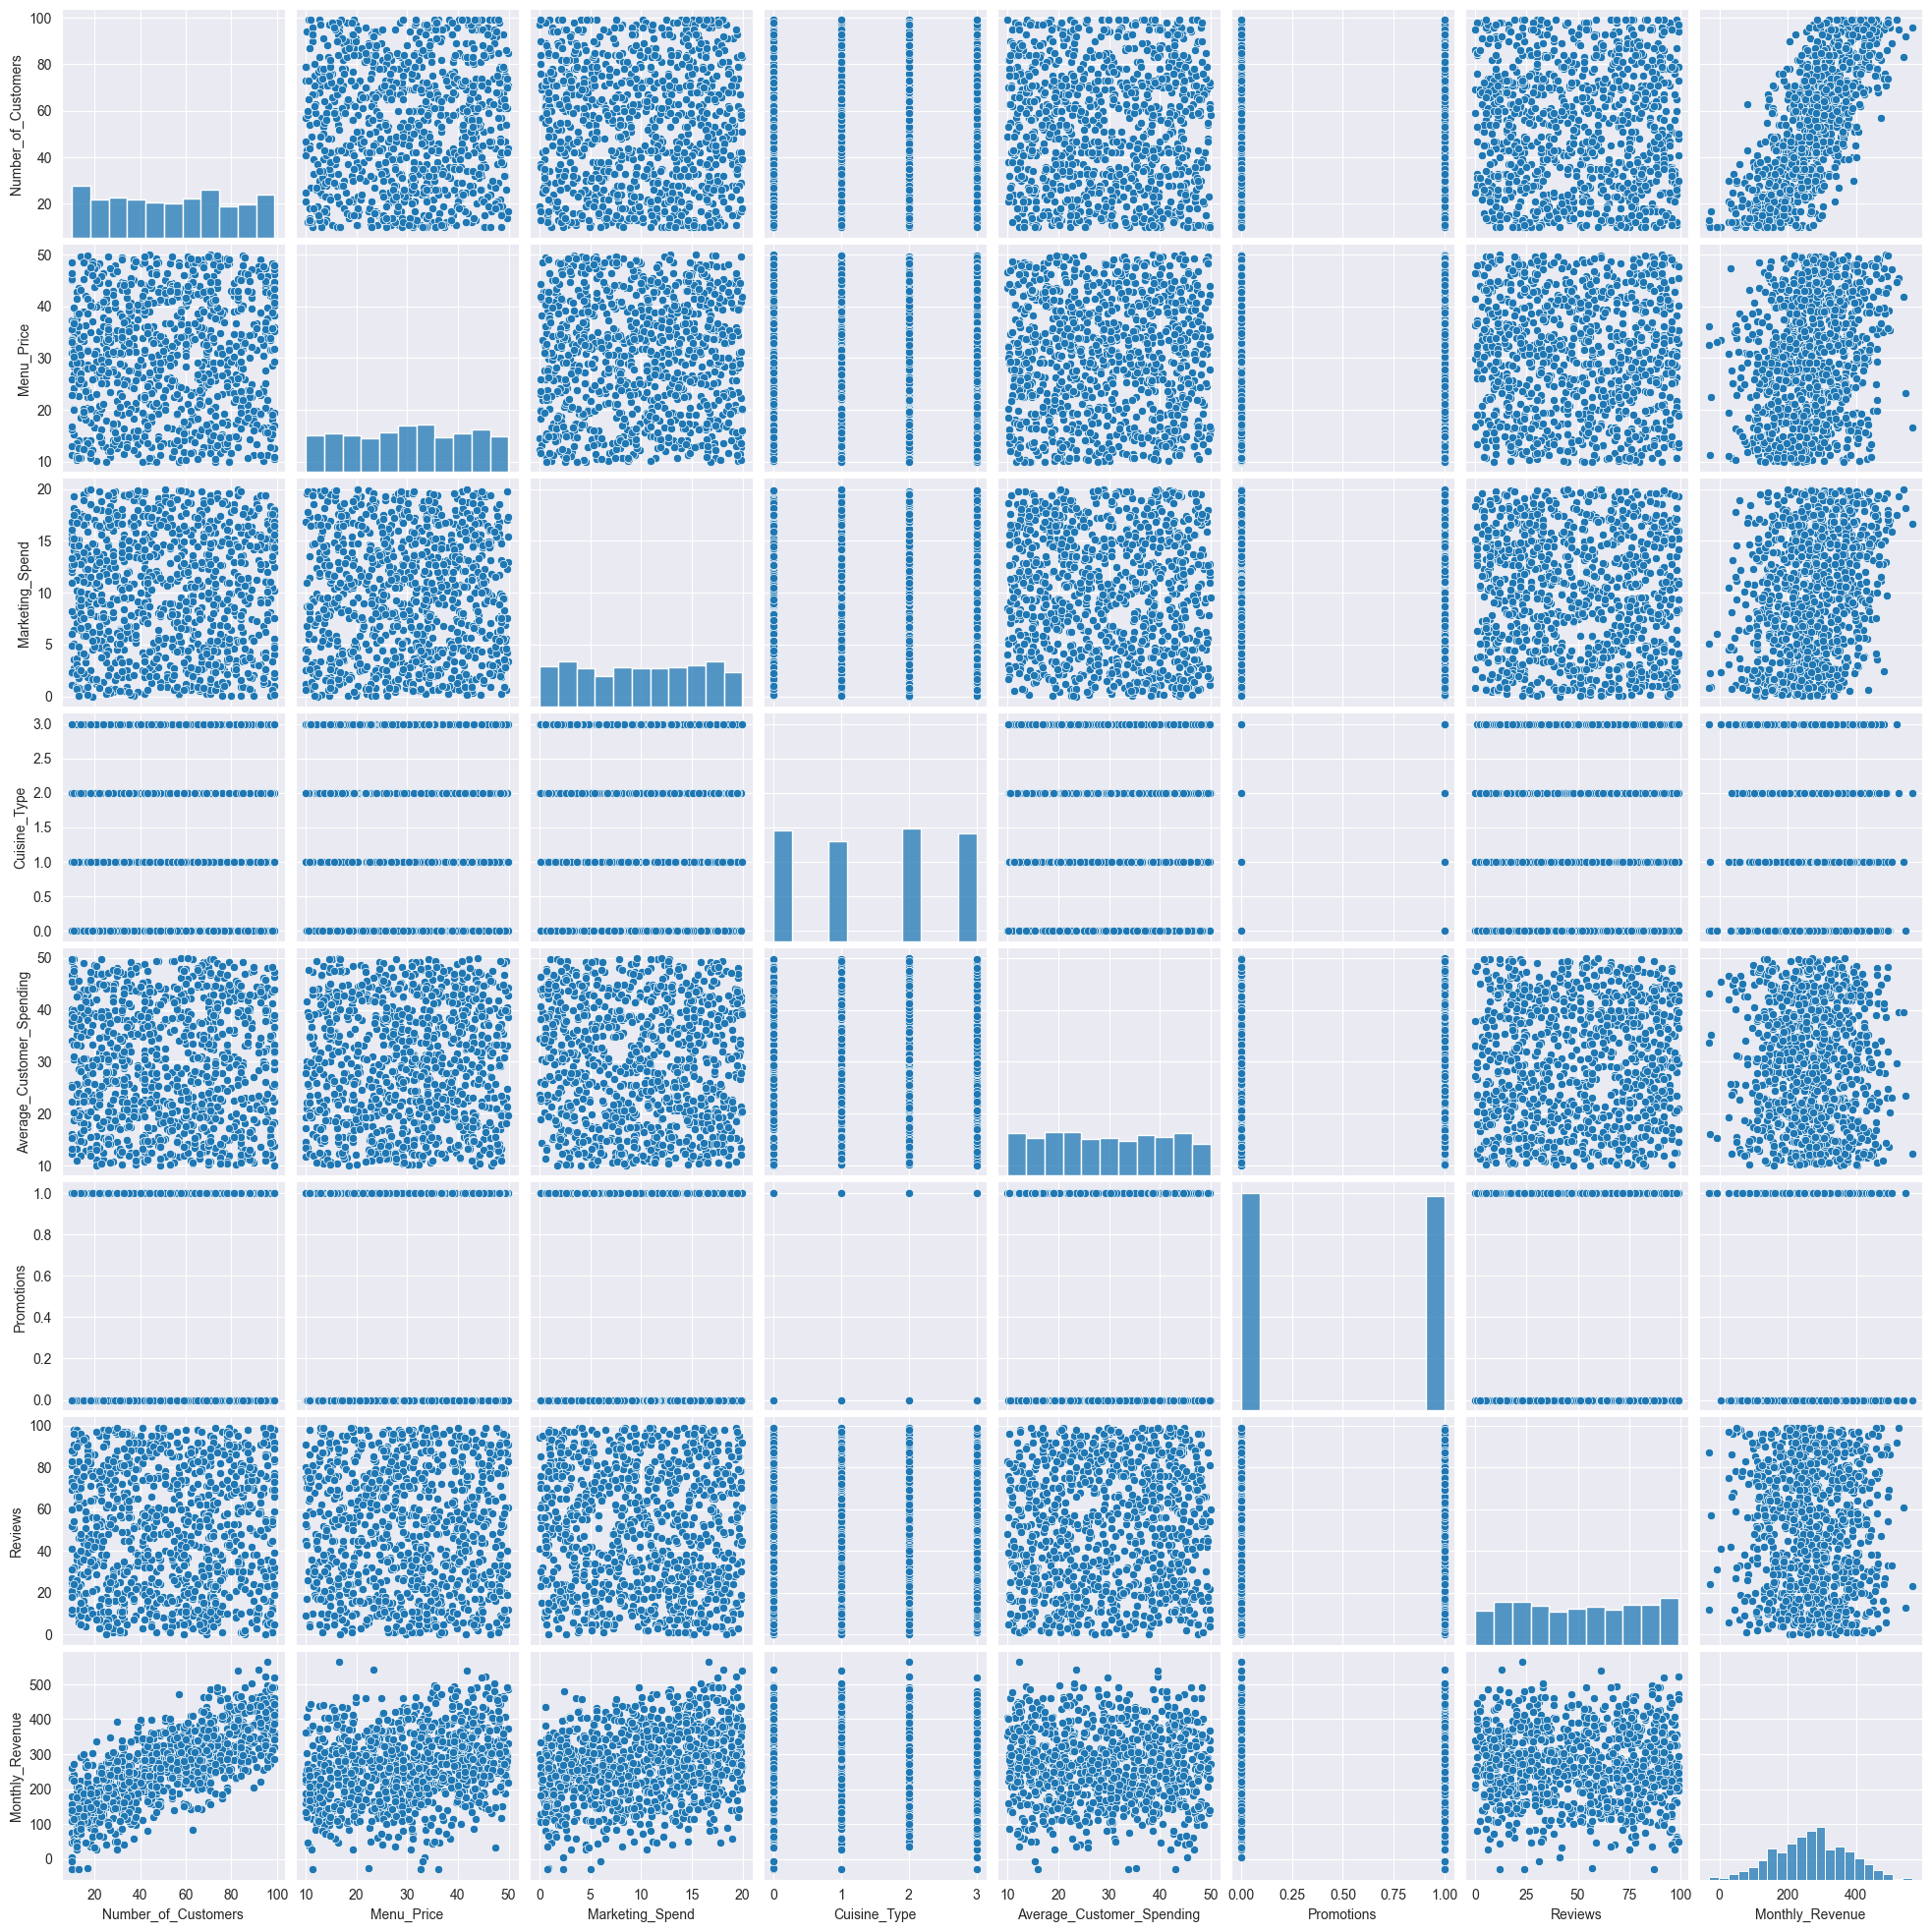

In [79]:
sns.pairplot(df)

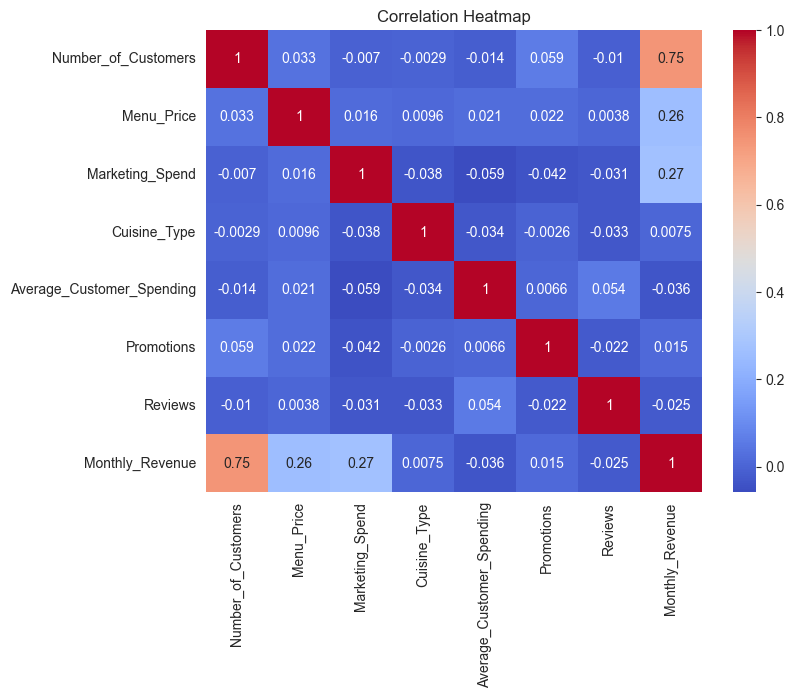

In [68]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

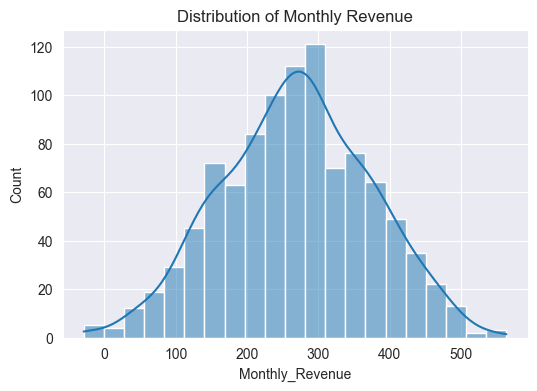

In [69]:
# Distribution of target variable
plt.figure(figsize=(6,4))
sns.histplot(df['Monthly_Revenue'], kde=True)
plt.title("Distribution of Monthly Revenue")
plt.show()

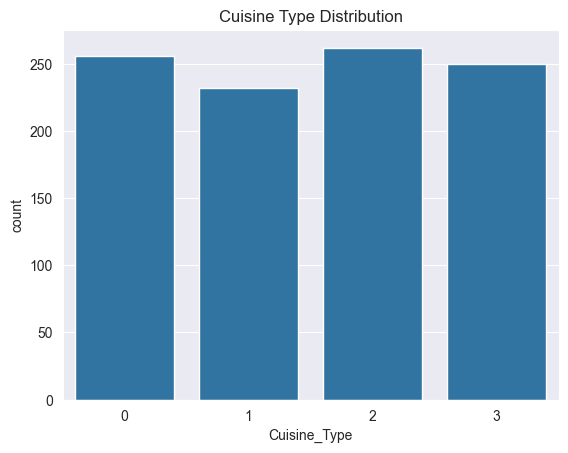

In [70]:
# Countplot for categorical column
sns.countplot(x="Cuisine_Type", data=df)
plt.title("Cuisine Type Distribution")
plt.show()

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Cuisine_Type               1000 non-null   int64  
 4   Average_Customer_Spending  1000 non-null   float64
 5   Promotions                 1000 non-null   int64  
 6   Reviews                    1000 non-null   int64  
 7   Monthly_Revenue            1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


# Splitting the data in train and to test to train model
### *Here i will use 20% data to test and 80% to train*

In [72]:
target_col = 'Reviews' # change if file has different column name
y = df[target_col]
X = df.drop(columns=[target_col])

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data

In [74]:
# Scaling numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modeling

# Initialising model 1

In [75]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Initialising Model 2

In [76]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Initialising model 3

In [77]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [78]:
def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Model: {model_name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R² Score:", r2)
    print("-"*40)

# Evaluate each model
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")


Model: Linear Regression
MAE: 25.27471781961935
MSE: 844.9547073208014
RMSE: 29.068104639291523
R² Score: -0.03798976833750389
----------------------------------------
Model: Decision Tree
MAE: 30.32
MSE: 1444.06
RMSE: 38.00078946548348
R² Score: -0.7739643224407362
----------------------------------------
Model: Random Forest
MAE: 25.336949999999998
MSE: 871.3691405000001
RMSE: 29.51896238860709
R² Score: -0.07043874002662576
----------------------------------------
